In [2]:
import pennylane as qml

import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import networkx as nx

All possible 3-qubit graph states

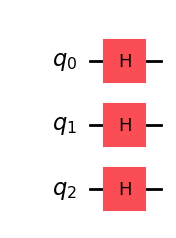

<IPython.core.display.Latex object>

Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))
[]


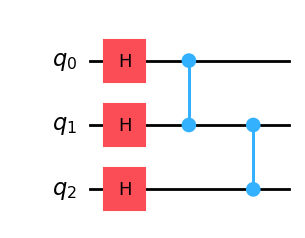

<IPython.core.display.Latex object>

Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
             -0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
             -0.35355339+0.j,  0.35355339+0.j],
            dims=(2, 2, 2))
[(0, 1), (1, 2)]


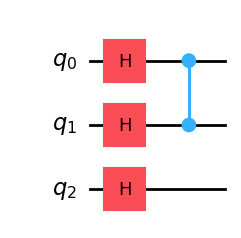

<IPython.core.display.Latex object>

Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
             -0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
              0.35355339+0.j, -0.35355339+0.j],
            dims=(2, 2, 2))
[(0, 1)]


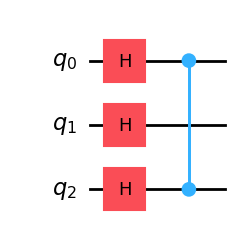

<IPython.core.display.Latex object>

Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
              0.35355339+0.j,  0.35355339+0.j, -0.35355339+0.j,
              0.35355339+0.j, -0.35355339+0.j],
            dims=(2, 2, 2))
[(0, 2)]


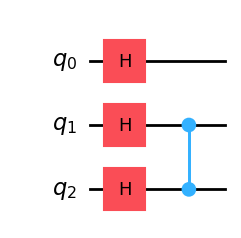

<IPython.core.display.Latex object>

Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
              0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
             -0.35355339+0.j, -0.35355339+0.j],
            dims=(2, 2, 2))
[(1, 2)]


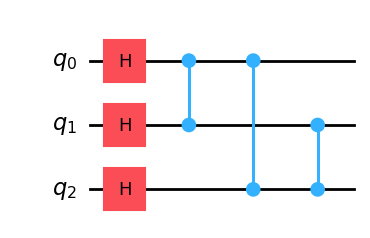

<IPython.core.display.Latex object>

Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
             -0.35355339+0.j,  0.35355339+0.j, -0.35355339+0.j,
             -0.35355339+0.j, -0.35355339+0.j],
            dims=(2, 2, 2))
[(0, 1), (0, 2), (1, 2)]


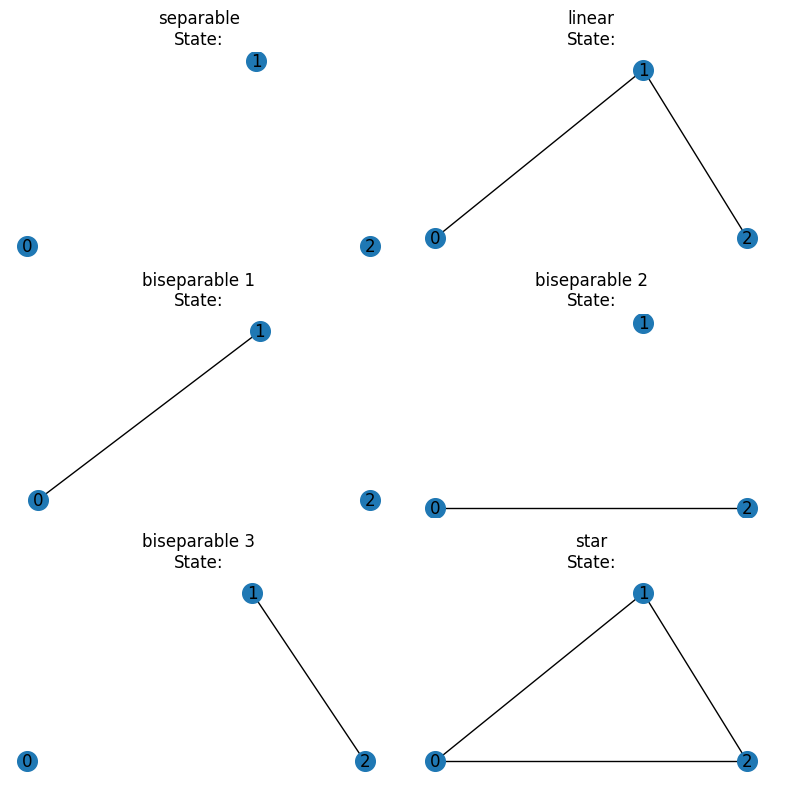

In [3]:
graph_states_3 = {
    'separable': [],
    'linear': [(0, 1), (1, 2)],
    'biseparable 1': [(0, 1)],
    'biseparable 2': [(0, 2)],
    'biseparable 3': [(1, 2)],
    'star': [(0, 1), (0, 2), (1, 2)]
}

def compute_statevectors(edges):
    circuit = QuantumCircuit(3)

    for i in range(3):
        circuit.h(i)
    
    for i, j in edges:
        circuit.cz(i, j)
    
    state = Statevector.from_instruction(circuit)
    
    return circuit, state

def plot_graph_states(graphs):
    fig, axes = plt.subplots(3, 2, figsize=(8, 8))
    axes = axes.flatten()

    for ax, (title, edges) in zip(axes, graphs.items()):
        circuit, state = compute_statevectors(edges)

        display(circuit.draw('mpl'))
        display(state.draw('latex'))
        print(state)
        print(edges)

        G = nx.Graph()

        G.add_nodes_from([0, 1, 2])
        G.add_edges_from(edges)
        
        pos = {
            0: (0, 0),
            1: (.8, .5),
            2: (1.2, 0)
        }
        nx.draw(G, pos, with_labels=True, node_size=200, ax=ax)
        
        ax.set_title(f"{title}\nState:")


    plt.tight_layout()
    plt.show()

plot_graph_states(graph_states_3)

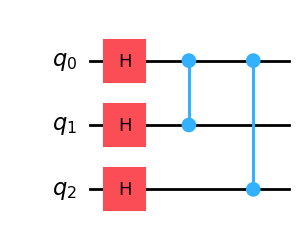

In [4]:
qc = QuantumCircuit(3)

for i in range(3):
    qc.h(i)

qc.cz(0, 1)
qc.cz(0, 2)

state = Statevector.from_instruction(qc)

qc.draw('mpl')

In [5]:
from qiskit.quantum_info import Operator

I = np.identity(2)
Z = np.array([
    [1, 0],
    [0, -1]
])

Z, I

(array([[ 1,  0],
        [ 0, -1]]),
 array([[1., 0.],
        [0., 1.]]))